In [159]:
import numpy as np
import pandas as pd

In [160]:
y = dataset = np.loadtxt("../Data/spambase.data",delimiter=",")

In [161]:
y = dataset[:, -1]

In [162]:
y

array([1., 1., 1., ..., 0., 0., 0.], shape=(4601,))

In [163]:
X = pd.DataFrame(dataset[:,:-1])

In [164]:
X

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.0,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3.0,88.0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4.0,14.0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6.0,118.0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5.0,78.0


In [165]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


In [166]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=32)

In [167]:
from sklearn.naive_bayes import GaussianNB


In [168]:
NB = GaussianNB()
NB.fit(X_train,y_train)
y_pred = NB.predict(X_test)

## EVALUATE

<Axes: >

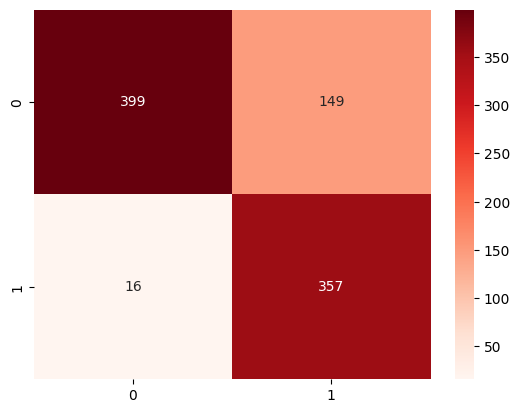

In [169]:
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Reds",fmt="d")

In [170]:
print(classification_report(y_pred,y_test))


              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83       415
         1.0       0.96      0.71      0.81       506

    accuracy                           0.82       921
   macro avg       0.84      0.83      0.82       921
weighted avg       0.85      0.82      0.82       921



c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

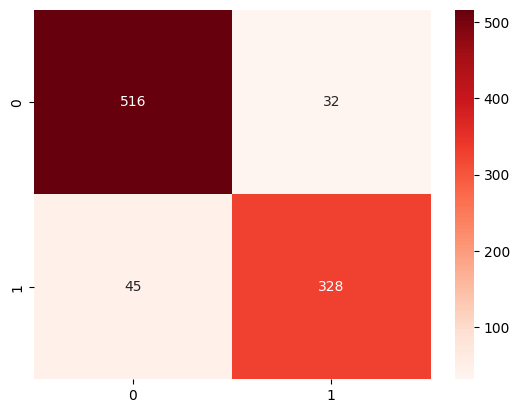

In [171]:
LR = LogisticRegression()
LR.fit(X_train,y_train)
y_pred = LR.predict(X_test)

cmLR = confusion_matrix(y_test,y_pred)
sns.heatmap(cmLR, annot=True,cmap="Reds",fmt="d")

In [172]:
print(classification_report(y_pred,y_test))



              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       561
         1.0       0.88      0.91      0.89       360

    accuracy                           0.92       921
   macro avg       0.91      0.92      0.91       921
weighted avg       0.92      0.92      0.92       921



## try with K=4 , 10,20 check the CM & the classification report.


<Axes: >

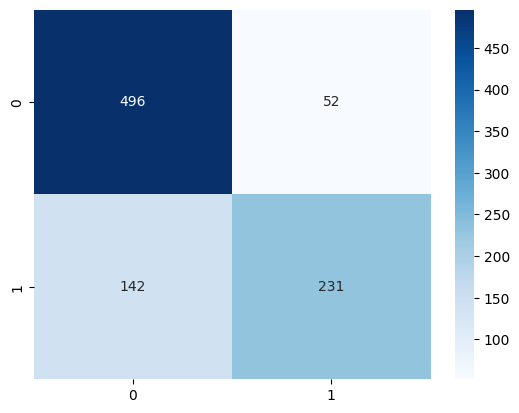

In [173]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

In [174]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84       548
         1.0       0.82      0.62      0.70       373

    accuracy                           0.79       921
   macro avg       0.80      0.76      0.77       921
weighted avg       0.79      0.79      0.78       921



<Axes: >

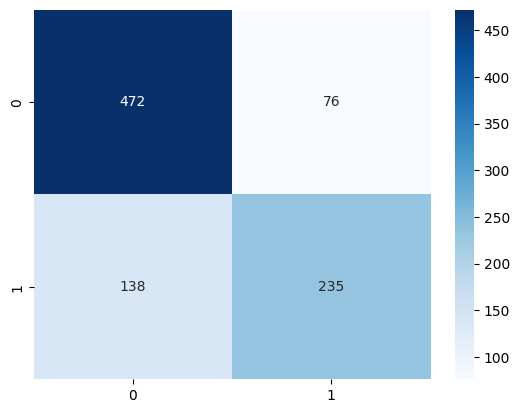

In [175]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

In [176]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.77      0.86      0.82       548
         1.0       0.76      0.63      0.69       373

    accuracy                           0.77       921
   macro avg       0.76      0.75      0.75       921
weighted avg       0.77      0.77      0.76       921



<Axes: >

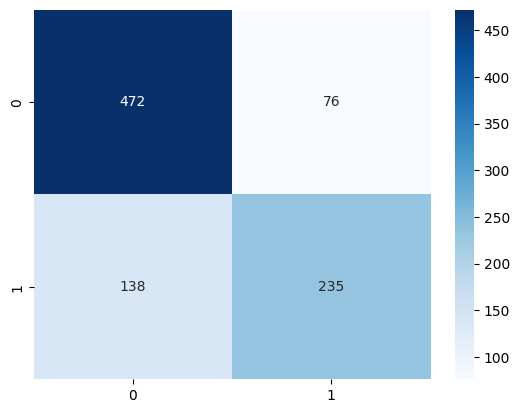

In [177]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.86      0.82       548
         1.0       0.76      0.63      0.69       373

    accuracy                           0.77       921
   macro avg       0.76      0.75      0.75       921
weighted avg       0.77      0.77      0.76       921



In [ ]:

accuracy = []
precision = []
f1 = []
recall = []
list_k = []
for k in range(1,20,1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    list_k.append(k)
    accuracy.append(accuracy_score(y_test,y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test,y_pred))
    f1.append(f1_score(y_test, y_pred))

In [1]:
metrics_df = pd.DataFrame({"K":list_k,"Acc":accuracy,"Pre":precision,"f1":f1,"recall":recall})
metrics_df.plot(x = "K",y = "Acc")
metrics_df.plot(x = "K",y = "Pre")
metrics_df.plot(x = "K",y = "f1")
metrics_df.plot(x = "K",y = "recall")

NameError: name 'pd' is not defined